### 2.2 Mumbai precipitation

Mumbai (Aw) precipitation source: https://data.opencity.in/dataset/mumbai-rainfall-data

This data is used to assess how decomposition performs if seasonality is given by water availability rather than radiation. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

<Axes: xlabel='Date'>

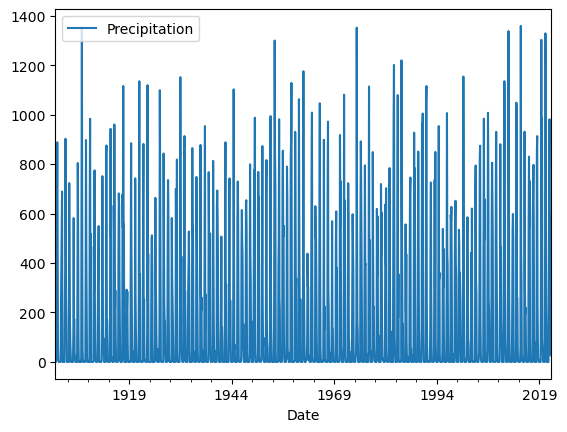

In [3]:
# Import Mumbai precipitation data
mumbai_precipitation = pd.read_csv('../data/mumbai-monthly-rains.csv')

mumbai_precipitation.drop(columns='Total', inplace=True)

# Define mapping to fix month names
month_mapping = {
    'Jan': 'Jan', 'Feb': 'Feb', 'Mar': 'Mar',
    'April': 'Apr', 'May': 'May', 'June': 'Jun', 'July': 'Jul',
    'Aug': 'Aug', 'Sept': 'Sep', 'Oct': 'Oct', 'Nov': 'Nov', 'Dec': 'Dec'
}

# Rename columns using the mapping
mumbai_precipitation.rename(columns=month_mapping, inplace=True)

# Melt the DataFrame
mumbai_precipitation_melted = mumbai_precipitation.melt(
    id_vars='Year',
    var_name='Month',
    value_name='Precipitation'
)

# Convert to datetime
mumbai_precipitation_melted['Date'] = pd.to_datetime(
    mumbai_precipitation_melted['Year'].astype(str) + '-' + mumbai_precipitation_melted['Month'],
    format='%Y-%b'
)

# Final cleanup
mumbai_precipitation_melted.drop(columns=['Year', 'Month'], inplace=True)
mumbai_precipitation_melted.set_index('Date', inplace=True)

mumbai_precipitation_melted.sort_index(inplace=True)

mumbai_precipitation_melted.plot()


### Seasonal decomposition

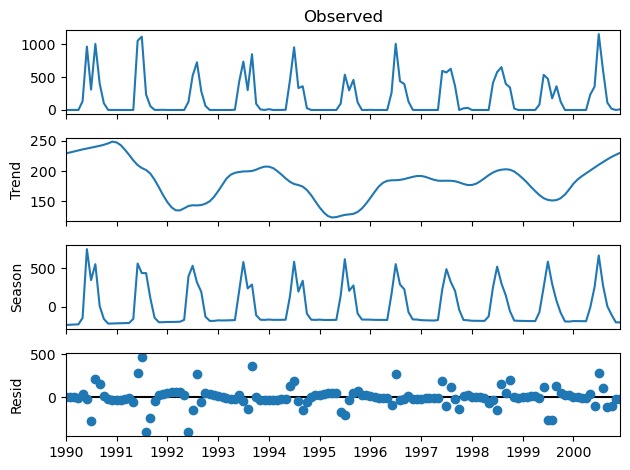

In [5]:
# Mumbai precipitation
dec_monsoon = STL(mumbai_precipitation_melted.loc['1990':'2000'], period=12).fit() # also only 10 years

# Visualize decomposition
dec_monsoon.plot()
plt.show()

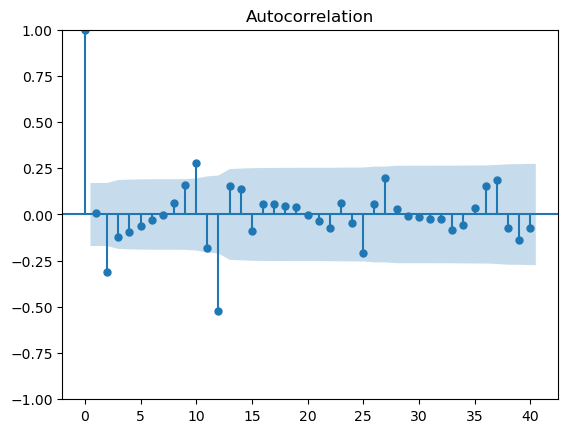

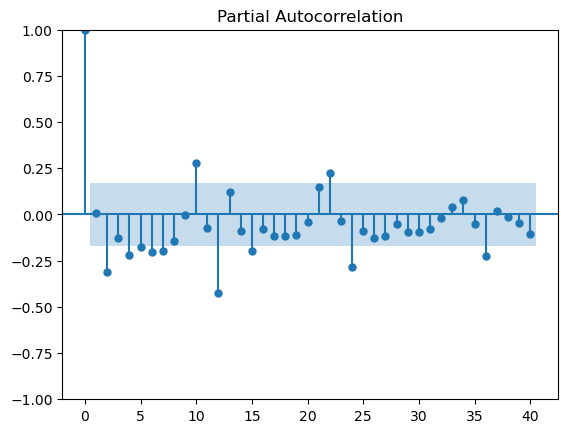

In [7]:
# ACF plot
plot_acf(dec_monsoon.resid, lags=40, alpha=0.05)
plt.show()

# PACF plot
plot_pacf(dec_monsoon.resid, lags=40, alpha=0.05)
plt.show()  

**Mumbai (Aw):** The plot shows several significant spikes. There are noticeable negative correlations around 3 and 12 (negative) and 10 (positive).

Interpretation of Residual Autocorrelation:

If the residuals of a time series model (like those from a decomposition) are truly white noise, their autocorrelation function should ideally show no significant correlations at any lag other than lag 0. The presence of significant autocorrelation in the residuals, as seen in this plot, suggests that there is still unexplained structure or dependence in the time series data that the decomposition model did not capture. Specifically, the significant spikes indicate that the residuals are not random and that past residual values can predict future residual values. This implies that the model might not be adequately capturing all the temporal dependencies in the original time series.

Possible Implications:

The underlying time series might have remaining seasonality or trend components that were not fully removed by the decomposition. There might be autocorrelation in the original series that the decomposition model didn't account for, indicating a need for a more sophisticated model (e.g., ARIMA or similar models) if the goal is to model and forecast the series. The presence of significant spikes at specific lags could suggest yearly or half-yearly seasonality that was not captured or fully removed by the decomposition if the data is, for example, monthly or bi-weekly.